In [39]:
# Cell 1: Setup
"""
# ArcticDEM Transect Elevation Profile Analysis
Extract and compare elevation profiles across multiple DEMs along a transect.
"""

import sys
sys.path.append('..')

import importlib
from config import OUTPUT_DIR, ARCHIVE_DIR
import analysis
importlib.reload(analysis)  # Reload modules to reflect any changes
from analysis import run_transect_analysis, plot_combined_profiles, additional_plots

import time
from ipyleaflet import (
    AwesomeIcon,
    FullScreenControl,
    GeoJSON,
    Polyline,
    Map,
    Marker,
    basemaps,
)
from IPython.display import clear_output, display
from ipywidgets import HTML, Button, HBox, Layout, VBox, widgets  # type: ignore
from pyproj import Transformer  # type: ignore
from rasterio import warp
from rasterio.features import shapes
from shapely.geometry import mapping, shape
from geopy.distance import geodesic as geopydistance  # type: ignore

########################################################################
def stac_api_transect(raster_data=None, raster_metadata=None, mask=None, timeout=2):
    """
    Function to use an interactive map allowing the user to select a transect using draggable markers.
    If a raster is provided, it will display its footprint.

    Parameters:
    -----------
    raster_data : ndarray, optional
        2D array of raster values (default: None)
    raster_metadata : dict, optional
        Metadata dictionary containing raster bounds, src and transform (default: None)
    mask : ndarray, optional
        Mask for the raster data (1 for valid, 0 for invalid) (default: None)
    timeout : int, optional
        Timeout in seconds for user interaction (default: 20)

    """
    global coords
    coords = (-54.2, 75, -54.3, 75.05)
    center_lon = -54.25
    center_lat = 75.025
    mid_lat = center_lat
    start_lon = coords[0] + (coords[2] - coords[0]) / 3
    end_lon = coords[0] + 2 * (coords[2] - coords[0]) / 3
    # Create a leaflet map widget to find an AOI for the spatial query of the STAC API
    m = Map(
        basemap=basemaps.Esri.WorldImagery,
        scroll_wheel_zoom=True,
        center=(center_lat, center_lon),
        zoom=6,
        layout=Layout(height="380px", width="700px"),
    )

    if raster_data is not None:
        # Transform raster bounds to WGS84 (EPSG:3857) for the map
        print(f"Raster shape: {raster_data.shape}")
        transform = raster_metadata["transform"]
        bounds = raster_metadata["bounds"]
        crs_src = raster_metadata["crs"]

        # Transform bounds to WGS84 (EPSG:4326) for the map # I thought it was EPSG:3857
        transformer = Transformer.from_crs(crs_src, "EPSG:4326", always_xy=True)
        lons, lats = transformer.transform(
            [bounds.left, bounds.right], [bounds.bottom, bounds.top]
        )
        west, east = lons
        south, north = lats

        bounds_wgs84 = (west, south, east, north)
        print(f"Raster bounds in WGS84: {bounds_wgs84}")

        # Calculate center of bounds
        center_lon = (bounds_wgs84[0] + bounds_wgs84[2]) / 2
        center_lat = (bounds_wgs84[1] + bounds_wgs84[3]) / 2

        # Extract shapes (this is the expensive step!)
        shapes_gen = shapes(mask, transform=transform)
        polygons = [shape(geom) for geom, val in shapes_gen if val == 1]

        if not polygons:
            raise ("Warning: No valid polygons found.")

        for i, poly in enumerate(polygons):
            # Transform polygon to WGS84
            wgs84_poly = warp.transform_geom(crs_src, "EPSG:4326", mapping(poly))
            geojson_poly = GeoJSON(
                data=wgs84_poly,
                style={
                    "color": "lime",
                    "fillColor": "lime",
                    "opacity": 0.8,
                    "fillOpacity": 0.2,
                    "weight": 2,
                },
                name=f"Raster Boundary {i+1}",
            )
            m.add_layer(geojson_poly)

        # Add markers at 1/3 and 2/3 of the raster's width
        start_lon = bounds_wgs84[0] + (bounds_wgs84[2] - bounds_wgs84[0]) / 3
        end_lon = bounds_wgs84[0] + 2 * (bounds_wgs84[2] - bounds_wgs84[0]) / 3
        mid_lat = (bounds_wgs84[1] + bounds_wgs84[3]) / 2

    m.add_control(FullScreenControl())
    result_output = widgets.Output()

    # Create info display
    info_html = HTML(
        value="<b>Drag the marker, then click Confirm</b>",
        layout=Layout(padding="10px"),
    )

    # Create confirmation button
    confirm_button = Button(
        description="Confirm Selected Points",
        button_style="success",
        disabled=False,
        tooltip="Click after placing marker",
    )

    # Create markers (initially slightly offset from center)
    start_marker = Marker(
        # location=(center_y, center_x - 0.1),
        location=(mid_lat, start_lon),  # Leaflet expects (lat, lon)
        draggable=True,
        name="Start (A)",
        icon=AwesomeIcon(name="play", marker_color="red"),
    )

    end_marker = Marker(
        # location=(center_y, center_x + 0.1),
        location=(mid_lat, end_lon),  # Leaflet expects (lat, lon)
        draggable=True,
        name="End (B)",
        icon=AwesomeIcon(name="stop", marker_color="blue"),
    )

    m.add_layer(start_marker)
    m.add_layer(end_marker)

    # Add line between markers
    line = Polyline(
        locations=[(mid_lat, start_lon), (mid_lat, end_lon)], color="purple", weight=3
    )
    m.add_layer(line)

    # Update line when markers move
    def update_line(*args):
        line.locations = [
            (start_marker.location[0], start_marker.location[1]),
            (end_marker.location[0], end_marker.location[1]),
        ]

    start_marker.observe(update_line, names=["location"])
    end_marker.observe(update_line, names=["location"])

    def update_display(*args):
        # Remember: Leaflet uses (lat, lon) format, but we want to store as (lon, lat)
        start_lat, start_lon = start_marker.location[0], start_marker.location[1]
        end_lat, end_lon = end_marker.location[0], end_marker.location[1]
        # Calculate distance between points
        dist = geopydistance((start_lat, start_lon), (end_lat, end_lon)).kilometers

        info_html.value = (
            f"<b>Current Positions:</b><br>"
            f"<span style='color:red'>Start (A):</span> Lon: {start_lon:.3f}, Lat: {start_lat:.3f}<br>"
            f"<span style='color:blue'>End (B):</span> Lon: {end_lon:.3f}, Lat: {end_lat:.3f}<br>"
            f"<span style='color:purple'>Distance:</span> {dist:.2f} km"
        )

    def on_confirm(b):
        global coords
        # Store as (lon, lat) for consistency with GIS conventions
        start_coords = (start_marker.location[1], start_marker.location[0])
        end_coords = (end_marker.location[1], end_marker.location[0])
        with result_output:
            result_output.clear_output()
            print(
                f"Points confirmed!\n\
                    Start (lon, lat): {start_coords[0]:.3f}, {start_coords[1]:.3f}\n\
                    End (lon, lat): {end_coords[0]:.3f}, {end_coords[1]:.3f}"
            )
            # Store results in global variable
            global coords
            coords = (start_coords, end_coords)

    confirm_button.on_click(on_confirm)
    start_marker.observe(update_display, names=["location"])
    end_marker.observe(update_display, names=["location"])
    update_display()  # Initial display update

    # Display all components
    display(VBox([info_html, m, HBox([confirm_button]), result_output]))

    # Wait for confirmation with timeout
    start_time = time.time()
    while (time.time() - start_time) < timeout:
        time.sleep(0.1)

    clear_output(wait=True)  # Clean up the display
    return coords

print("✓ Modules loaded")

✓ Modules loaded


In [11]:
# Cell 2: Configure Parameters
"""
## Configuration
"""

# Analysis parameters
TIME_RANGE = "2011-01-01/2026-12-31"
MAX_DEMS = 5                          # Maximum number of DEMs to process
COREG_MODE = 'none'                    # 'none', 'altim', or 'mosaic'
LAKE_NAME = None                       # Optional name for plots (e.g., "Lake X")
REF_YEAR = None                        # Optional reference year for relative difference plots (e.g., 2015)
MAX_CLOUD_COVER = 0.2                  # Maximum cloud cover fraction for filtering DEMs

# Coordinate selection
USE_INTERACTIVE_MAP = True

print(f"Archive: {ARCHIVE_DIR}")
print(f"Time range: {TIME_RANGE}")
print(f"Max DEMs: {MAX_DEMS}")
print(f"Coregistration: {COREG_MODE}")
print(f"Lake name: {LAKE_NAME}")
print(f"Max cloud cover: {MAX_CLOUD_COVER}")

Archive: /home/moralpom/luna/CPOM/archive/SATS/OPTICAL/ArcticDEM/strips/s2s041/2m/
Time range: 2011-01-01/2026-12-31
Max DEMs: 5
Coregistration: none
Lake name: None
Max cloud cover: 0.2


In [3]:
# Cell 3: Select Transect
"""
## Define Transect
Select start and end points for the elevation profile.
"""

if USE_INTERACTIVE_MAP:
    print("Use the map to define your transect...")
    print("Drag the RED marker (start) and BLUE marker (end)")
    coords = stac_api_transect(
        timeout=2
    )
else:
    coord_input = input(
        "Enter coordinates as lon1,lat1,lon2,lat2 "
        "(e.g. -54.2,75.0,-54.3,75.05): "
    )
    parts = list(map(float, coord_input.split(',')))
    coords = ((parts[0], parts[1]), (parts[2], parts[3]))


Use the map to define your transect...
Drag the RED marker (start) and BLUE marker (end)


In [40]:
# Cell 4: Run Analysis
"""
## Process Elevation Profiles
Query STAC API and extract profiles from all available DEMs.
"""
start, end = coords
print(f"\n✓ Start: ({start[0]:.3f}°E, {start[1]:.3f}°N)")
print(f"✓ End:   ({end[0]:.3f}°E, {end[1]:.3f}°N)")

profiles = run_transect_analysis(
    archdir=ARCHIVE_DIR,
    transect_coords=coords,
    time_range=TIME_RANGE,
    max_dems=MAX_DEMS,
    coreg_mode=COREG_MODE,
    lake_name=LAKE_NAME,
    max_cloud_cover=MAX_CLOUD_COVER
)

print(f"\n✓ Analysis complete!")
print(f"Successfully processed {len(profiles['profiles'])} profiles")


✓ Start: (-66.094°E, 77.952°N)
✓ End:   (-65.742°E, 77.934°N)
Transect: (-66.094, 77.952) -> (-65.742, 77.934)
Found 46 StripDEMs
After cloud filter (<20%): 39 DEMs
After xtrack filter: 32 DEMs
Downsampled to 5 DEMs
Finding mosaic file for coordinates ((-66.09375000000001, 77.95241384715757), (-65.74218750000001, 77.93405519690263))
✓ Both points are in the same mosaic tile: 28_36_2_1
Using mosaic file: /home/moralpom/luna/CPOM/archive/SATS/OPTICAL/ArcticDEM/mosaic/v4.1/2m/28_36/28_36_2_1_2m_v4.1_dem.tif
Elevation range: 1410.0 to 1445.7 meters
Mosaic profile extracted successfully.

Processing 5 DEMs for elevation profiles...


 20%|██        | 1/5 [00:17<01:11, 17.81s/it]

Elevation range: 1409.6 to 1445.0 meters
Transect length: 0.0 to 8289.9 m
First valid elevation at index: 0
First valid elevation at distance: 0.0 m


 40%|████      | 2/5 [00:38<00:57, 19.25s/it]

Elevation range: 1410.7 to 1431.6 meters
Transect length: 0.0 to 8289.9 m
First valid elevation at index: 0
First valid elevation at distance: 0.0 m


...

 80%|████████  | 4/5 [01:08<00:16, 16.15s/it]

Elevation range: 1409.1 to 1444.4 meters
Transect length: 0.0 to 8289.9 m
First valid elevation at index: 0
First valid elevation at distance: 0.0 m


100%|██████████| 5/5 [01:19<00:00, 15.91s/it]

Elevation range: 1411.7 to 1446.0 meters
Transect length: 0.0 to 8289.9 m
First valid elevation at index: 13
First valid elevation at distance: 1088.6 m
Successfully processed 5 profiles
Data saved: /home/moralpom/luna/CPOM/moralpom/globe/data/ArcticDEM/elevation_histories/transects_combined/combined_profiles_-66.094_77.952_-65.742_77.934_2011-2026_none.txt


Unzipping .gz file: .../n77w066/SETSM_s2s041_WV01_20240830_10200101026D3800_1020010102DBC900_2m_seg1.tar.gz
Opening gzip file
Copying gzip content to tar file
Opening tar file and extracting...
Median elevation: 1426.2 ± 11.0 m
Y-axis limits: 1399.34 to 1456.35
Range: 35.63, Padding: 10.69
Combined profile plot saved to: /home/moralpom/luna/CPOM/moralpom/globe/data/ArcticDEM/elevation_histories/transects_combined/profile_-66.094_77.952_-65.742_77.934-2012-2024_none.png

✓ Analysis complete!
Successfully processed 5 profiles



=== Generating elevation change heatmap and relative difference plots ===
Heatmap saved to: /home/moralpom/luna/CPOM/moralpom/globe/data/ArcticDEM/elevation_histories/transects_combined/diff_heatmap_-66.094_77.952_-65.742_77.934.png
Plot saved to: /home/moralpom/luna/CPOM/moralpom/globe/data/ArcticDEM/elevation_histories/transects_combined/profile_diff_-66.094_77.952_-65.742_77.934_none.png


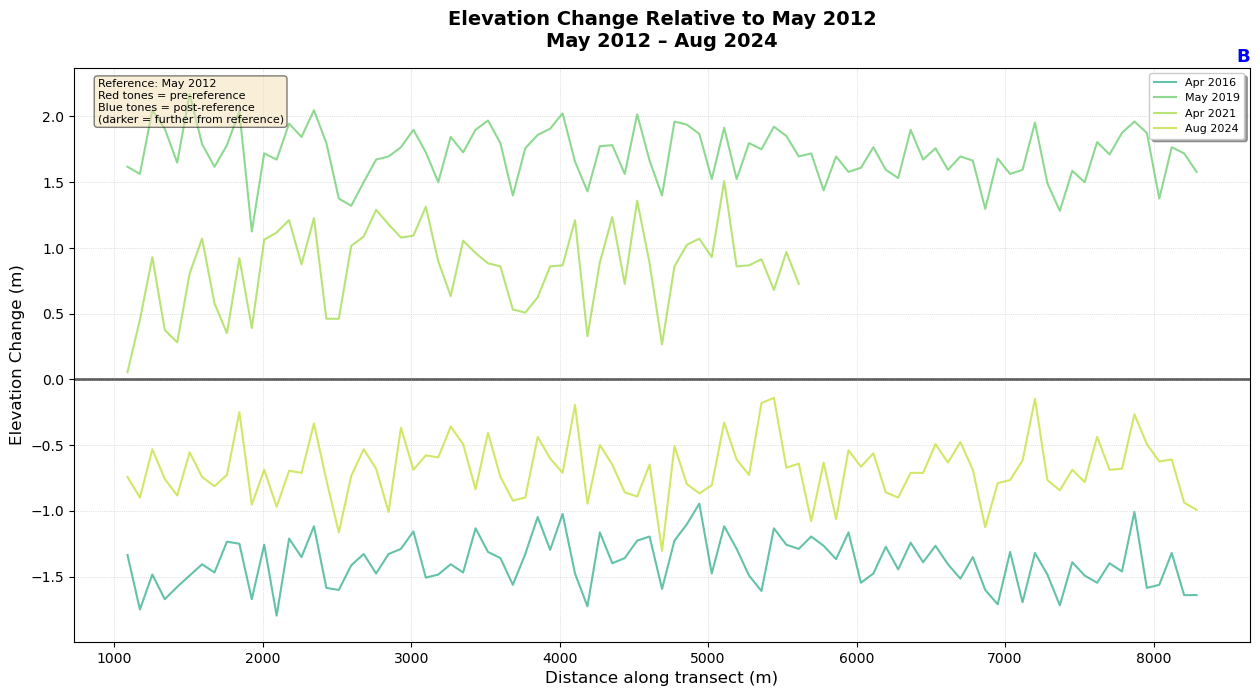

In [19]:
# Cell 5: Additional Plots (Heatmap and Relative Change)
"""
## Additional Plots
Heatmap and relative change plots for the profiles.
"""
additional_plots(profiles, reference_year=None, coreg_mode=COREG_MODE, lake_name=LAKE_NAME)

Plot saved to: /home/moralpom/luna/CPOM/moralpom/globe/data/ArcticDEM/elevation_histories/transects_combined/profile_-66.094_77.952_-65.742_77.934-WV01-WV01_none.png


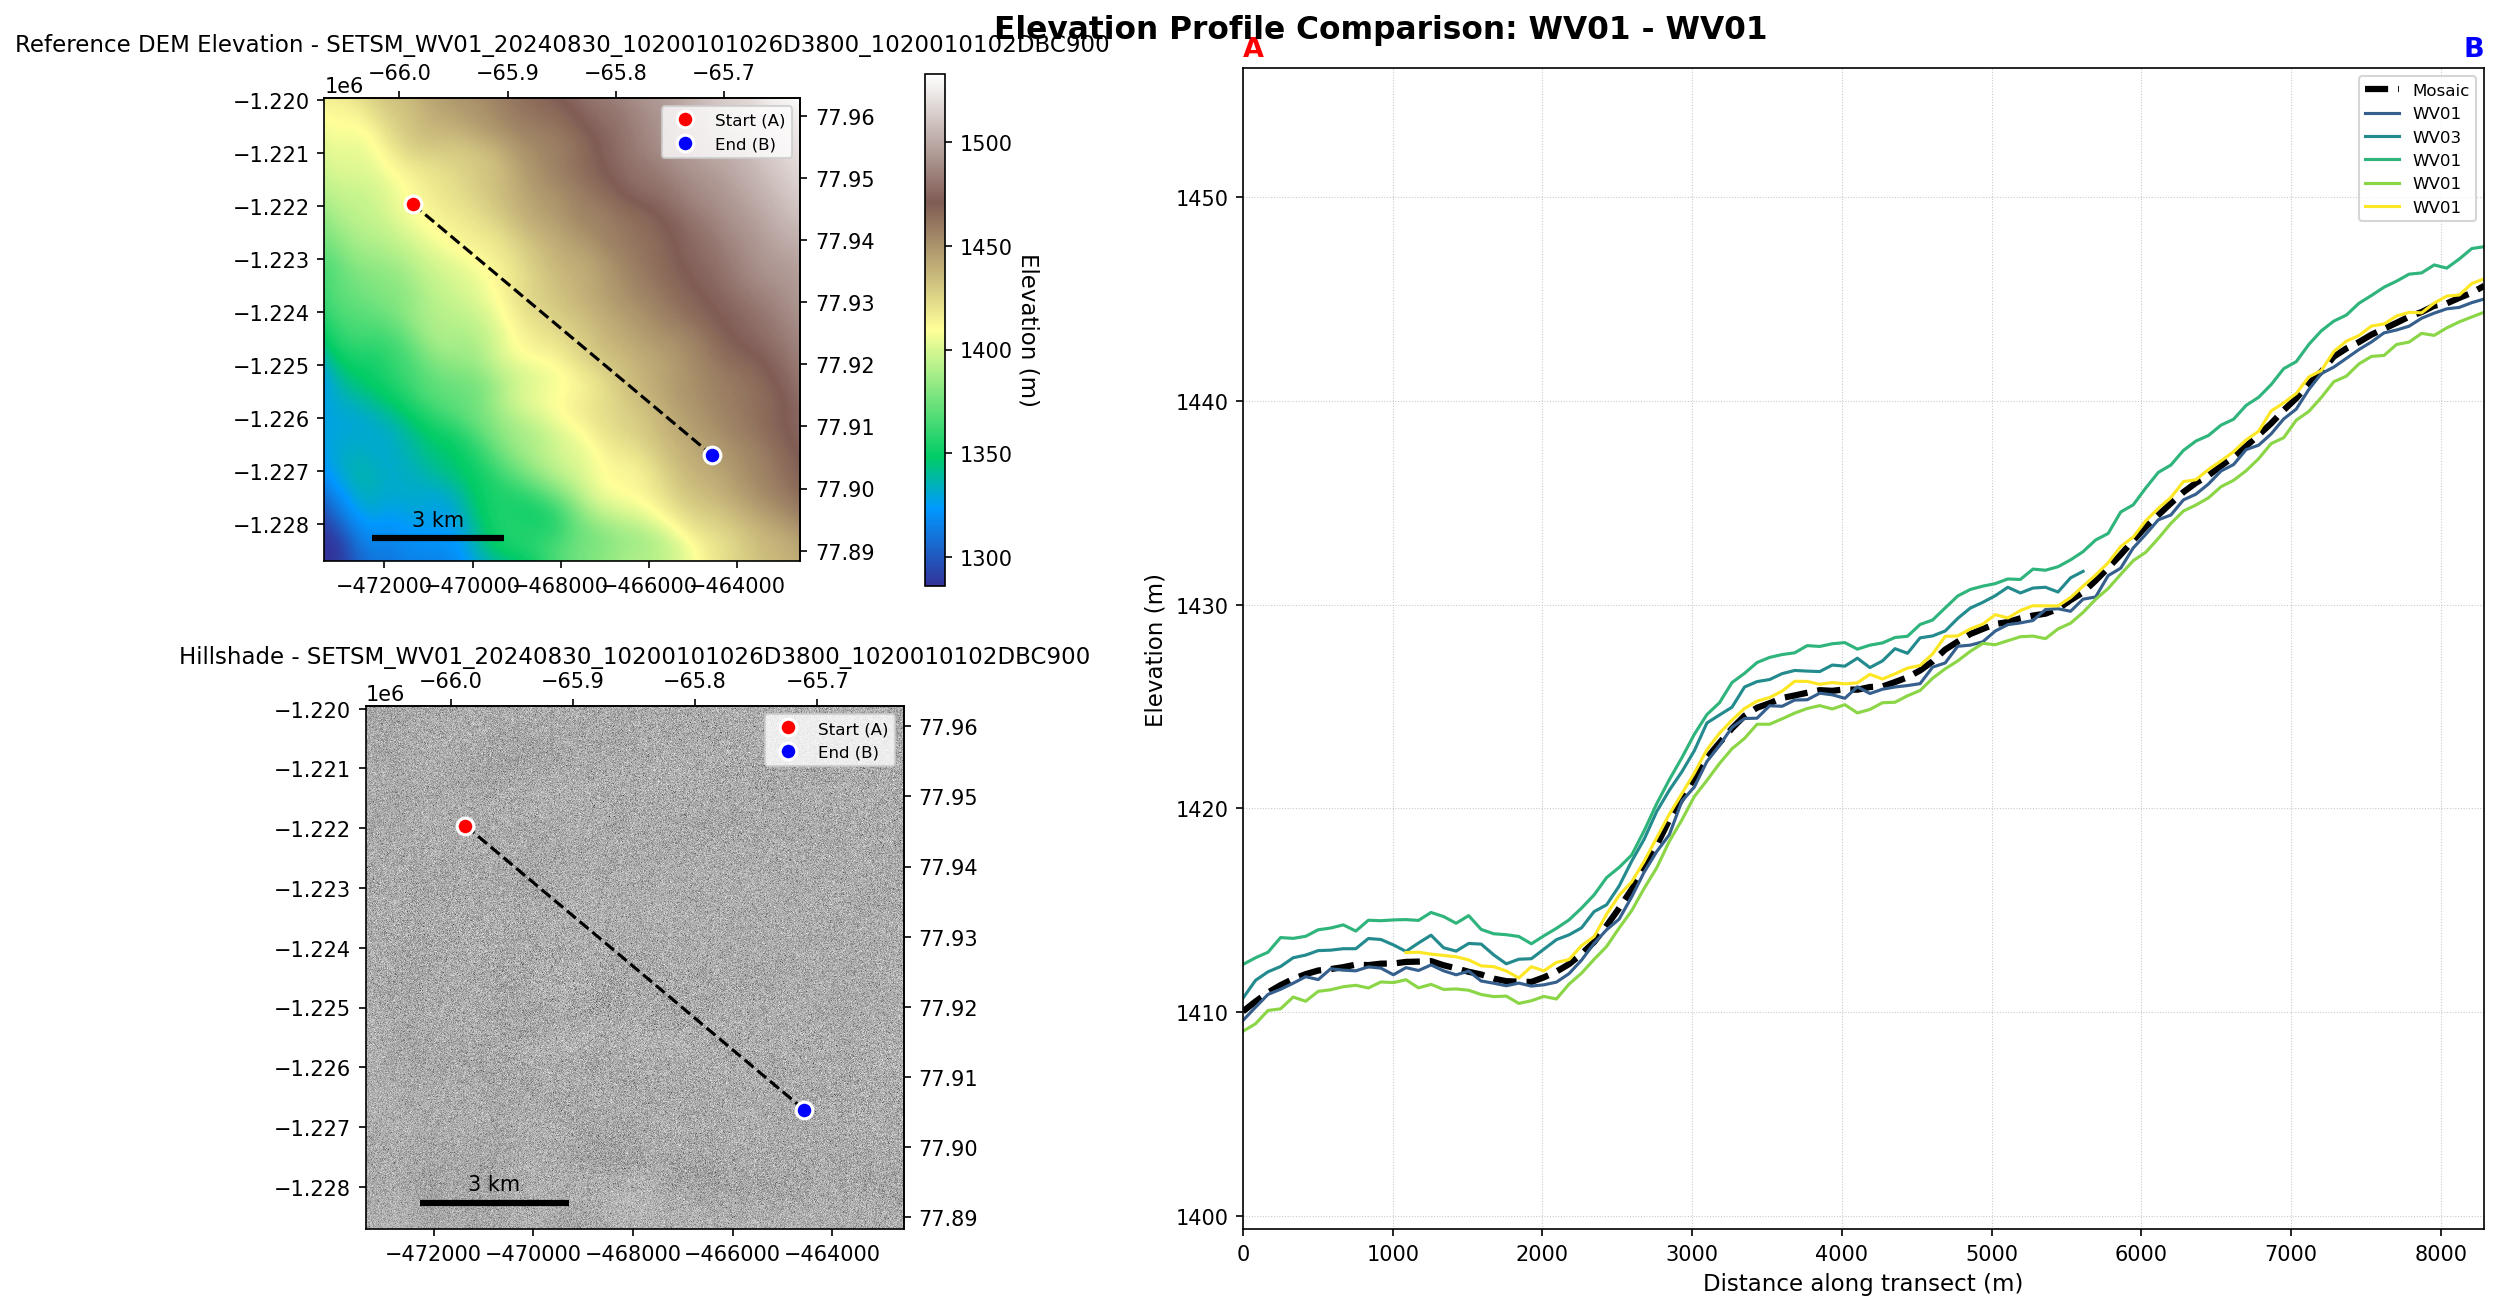

In [6]:
# Cell 5: View Results
"""
## Results
Combined profile plot with DEM context.
"""

from IPython.display import Image, display

if profiles.get('plot_path'):
    print(f"Plot saved to: {profiles['plot_path']}")
    display(Image(filename=profiles['plot_path']))

In [7]:
# Cell 6: Quick Statistics
"""
## Profile Statistics
Summary statistics for all processed DEMs.
"""

import numpy as np

print(f"\n{'DEM Name':<60} {'Min Elev':>10} {'Max Elev':>10} {'Mean':>10} {'Std Dev':>10}")
print("-" * 105)

for profile in profiles['profiles']:
    name = profile['metadata']['dem_name']
    elevations = profile['profile_values']
    valid = elevations[~np.isnan(elevations)]
    
    if len(valid) > 0:
        print(f"{name:<60} {np.min(valid):>10.1f} {np.max(valid):>10.1f} {np.mean(valid):>10.1f} {np.std(valid):>10.1f}")
    else:
        print(f"{name:<60} {'N/A':>10} {'N/A':>10} {'N/A':>10} {'N/A':>10}")


DEM Name                                                       Min Elev   Max Elev       Mean    Std Dev
---------------------------------------------------------------------------------------------------------
SETSM_WV01_20240830_10200101026D3800_1020010102DBC900            1409.6     1445.0     1425.5       11.3
SETSM_WV03_20210424_1040010068174F00_104001006890CE00            1410.7     1431.6     1420.6        7.3
SETSM_WV01_20190520_10200100849A2F00_1020010083C4E600            1412.3     1447.6     1427.9       11.3
SETSM_WV01_20160418_102001004BB36300_102001004FCB4B00            1409.1     1444.4     1424.8       11.3
SETSM_WV01_20120512_102001001B335300_1020010019C3A800            1411.7     1446.0     1428.3       10.6
